In [29]:
import pandas as pd

# Đọc file thứ nhất
df_kien = pd.read_csv("kien_label.csv", encoding='utf-8-sig')

# Đọc file thứ hai
df_thai = pd.read_csv("thai_label.csv", encoding='utf-8-sig')

# Đọc file thứ ba
df_vu = pd.read_csv("vu_label.csv", encoding='utf-8-sig')


print(f"Số dòng file Kiên: {len(df_kien)}")
print(f"Số dòng file Thái: {len(df_thai)}")
print(f"Số dòng file Thái: {len(df_vu)}")

# Gộp hai dataframe lại thành một
df_total = pd.concat([df_kien, df_thai], ignore_index=True)

print(f"Tổng số dòng sau khi gộp: {len(df_total)}")

mappings = {
    'CLEAN': 0,
    'OFFENSIVE': 1,
    'HATE': 2
}

df_total = df_total[['comment', 'sentiment']].copy()

df_total['label_id'] = df_total['sentiment'].map(mappings)

# Chỉ giữ lại comment và label_id
df_total = df_total[['comment', 'label_id']].copy()
df_total = df_total.rename(columns={'sentiment':'label_id'})


df_vu = df_vu[['comment','label_id']].copy()


df_final = pd.concat([df_vu, df_total], ignore_index=True)

Số dòng file Kiên: 2078
Số dòng file Thái: 2102
Số dòng file Thái: 4044
Tổng số dòng sau khi gộp: 4180


In [32]:
df_final.columns
df_final['label_id'].value_counts()

label_id
0.0    5635
2.0     407
1.0     225
Name: count, dtype: int64

In [37]:
import pandas as pd

# Đọc file JSON vừa lưu
df_gen = pd.read_json("generated_comments.json")

# Lưu sang CSV để đồng bộ định dạng với các file cũ
df_gen.to_csv("generated_data_final.csv", index=False, encoding="utf-8-sig")

In [74]:
df_final_data = pd.concat([df_final, df_gen], ignore_index=True)

In [102]:
df_final_data['label_id'].value_counts()
df_final_data = df_final_data[['comment', 'label_id']]
df_final_data['comment'].value_counts()

df_final_data['comment'] = df_final_data['comment'].str.lower()

# 2. Loại bỏ khoảng trắng thừa ở đầu và cuối câu
df_final_data['comment'] = df_final_data['comment'].str.strip()

# 3. Loại bỏ các dòng trùng lặp sau khi đã chuẩn hóa
df_final_data = df_final_data.drop_duplicates(subset=['comment'], keep='first')

# Giả sử df_final là dataframe tổng hợp của bạn
# keep='first' sẽ giữ lại dòng đầu tiên và xóa các dòng trùng sau đó

df_final_data['comment'] = df_final_data['comment'].str.replace(r'#\w+', '', regex=True)

df_final_data['comment'] = df_final_data['comment'].str.replace(r'\s+', ' ', regex=True).str.strip()

# 1. Loại bỏ các dòng mà cột 'label_id' hoặc 'comment' bị trống
df_final_data = df_final_data.dropna(subset=['label_id', 'comment'])

# 2. Loại bỏ các dòng mà comment chỉ chứa khoảng trắng (không có chữ)
df_final_data = df_final_data[df_final_data['comment'].str.strip() != ""]

# Kiểm tra lại kết quả
print("Label nan sau khi xử lý:", df_final_data['label_id'].isna().sum())
print("Số dòng còn lại:", len(df_final_data))

print(f"Số dòng trước khi clean: {len(df_final_data)}")


Label nan sau khi xử lý: 0
Số dòng còn lại: 9155
Số dòng trước khi clean: 9155


In [103]:
print("Label null:", df_final_data['label_id'].isnull().sum())
print("Label nan:",df_final_data['label_id'].isna().sum())

Label null: 0
Label nan: 0


C:\Users\hongk\AppData\Local\Temp\ipykernel_27500\2551731446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label_id', data=df_final_data, palette='viridis')


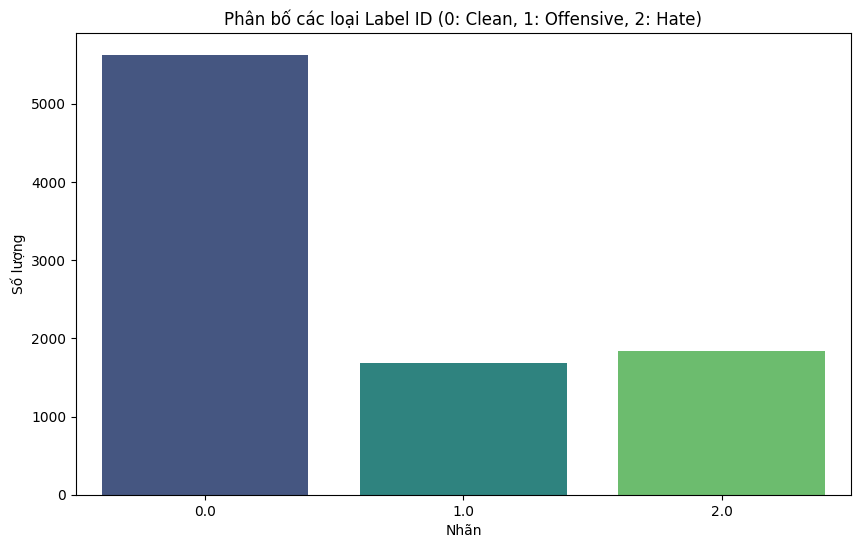

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập font để hiển thị tiếng Việt (nếu cần)
plt.rcParams['figure.figsize'] = (10, 6)

# Vẽ biểu đồ cột
sns.countplot(x='label_id', data=df_final_data, palette='viridis')
plt.title('Phân bố các loại Label ID (0: Clean, 1: Offensive, 2: Hate)')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.show()

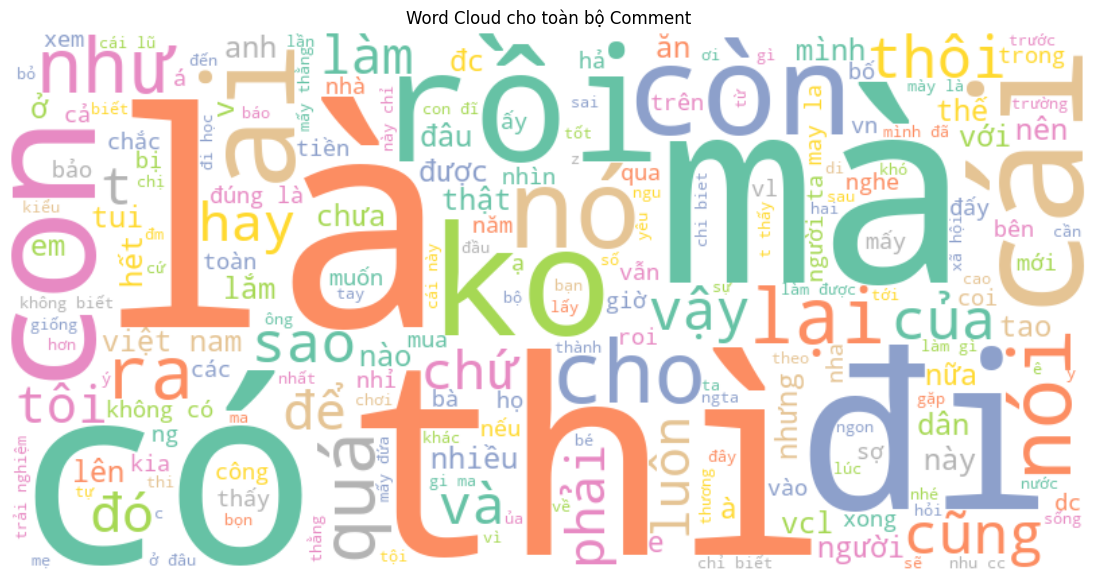

In [105]:
from wordcloud import WordCloud

# Kết hợp tất cả comment thành một chuỗi văn bản lớn
text = " ".join(review for review in df_final_data.comment.astype(str))

# Tạo WordCloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    max_words=200,
    colormap='Set2'
).generate(text)

# Hiển thị
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud cho toàn bộ Comment')
plt.show()

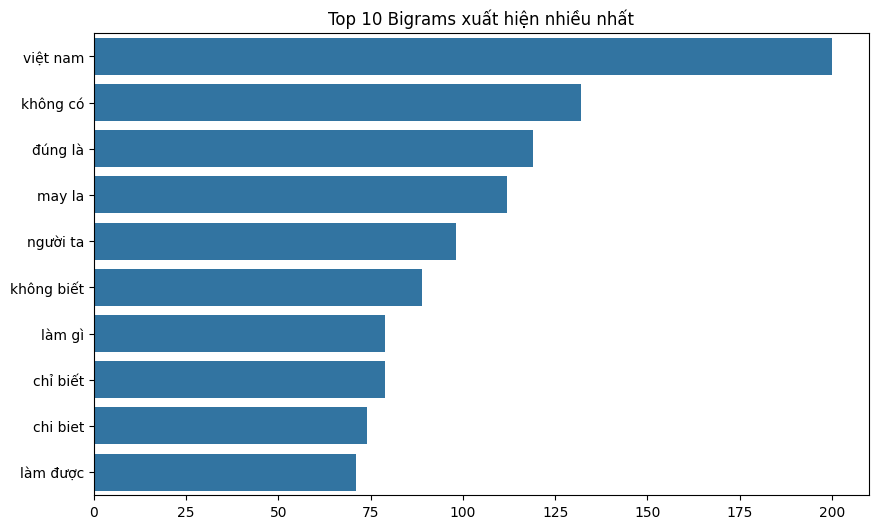

In [106]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Ví dụ lấy Top 10 Bigrams (cụm 2 từ)
top_bigrams = get_top_ngram(df_final_data['comment'].astype(str), n=2, top_k=10)
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(10, 6))
sns.barplot(x=y, y=x)
plt.title('Top 10 Bigrams xuất hiện nhiều nhất')
plt.show()

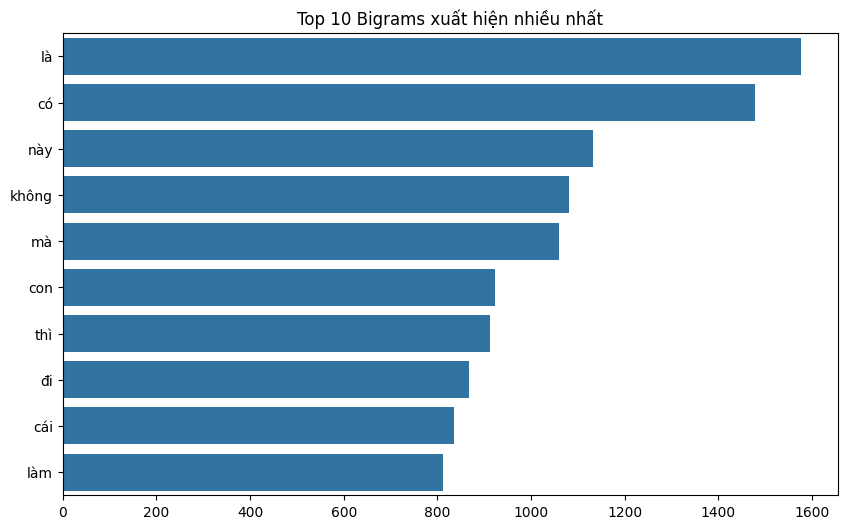

In [90]:
# Ví dụ lấy Top 10 Bigrams (cụm 2 từ)
top_bigrams = get_top_ngram(df_final_data['comment'].astype(str), n=1, top_k=10)
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(10, 6))
sns.barplot(x=y, y=x)
plt.title('Top 10 Bigrams xuất hiện nhiều nhất')
plt.show()

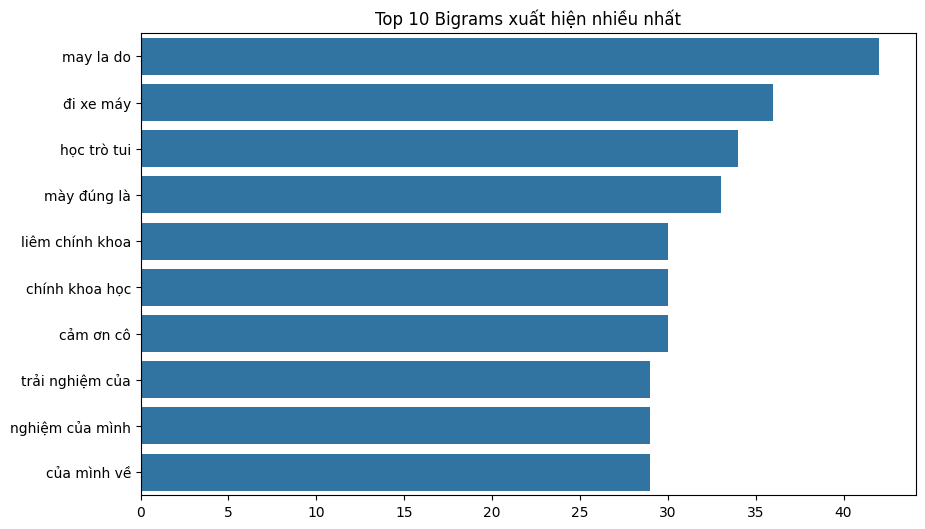

In [91]:
# Ví dụ lấy Top 10 Bigrams (cụm 2 từ)
top_bigrams = get_top_ngram(df_final_data['comment'].astype(str), n=3, top_k=10)
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(10, 6))
sns.barplot(x=y, y=x)
plt.title('Top 10 Bigrams xuất hiện nhiều nhất')
plt.show()

In [107]:
df_final_data.to_csv("final_data.csv", index=False, encoding='utf-8-sig')

print("đã lưu file CSV thành công!")

đã lưu file CSV thành công!
